# Phase 3 — Data Cleaning & EDA

Exploratory review of the `data/processed/` output produced by `backend/app/services/cleaning.py`:
schema/dtype sanity checks, missing-value counts, cleaning-stage drop statistics, gap analysis
(weekend/market-closed and any unexplained gaps), and basic price plots for each asset's D1
(daily) backbone series.

**Scope reminder:** this is a research artifact over historical data only — nothing here
touches live/real-time data. See the project root `README.md` for the full disclaimer.

In [1]:
import json
import sys
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

sys.path.insert(0, str(Path.cwd().parent / "backend"))
from app.config import ASSETS, Timeframe  # noqa: E402

PROJECT_ROOT = Path.cwd().parent
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"

pd.set_option("display.width", 160)
plt.rcParams["figure.figsize"] = (11, 4)

ASSET_KEYS = list(ASSETS.keys())
TIMEFRAMES = ["M15", "H1", "H4", "D1"]
print("Assets:", ASSET_KEYS)
print("Timeframes:", TIMEFRAMES)
print("Processed dir:", PROCESSED_DIR)

Assets: ['EURUSD', 'BTCUSD', 'XAUUSD']
Timeframes: ['M15', 'H1', 'H4', 'D1']
Processed dir: D:\Claude\market-intelligence-platform\data\processed


## Load the latest processed file per (asset, timeframe)

Each cleaning run writes a new, uniquely-timestamped parquet + manifest — this loads the
*latest* one for each combination, exactly as later phases (feature engineering, Phase 4+)
will.

In [2]:
def latest_processed(asset_key: str, timeframe: str):
    manifests = sorted(PROCESSED_DIR.glob(f"{asset_key}_{timeframe}_*.manifest.json"))
    if not manifests:
        return None, None
    manifest_path = manifests[-1]
    parquet_path = manifest_path.with_suffix("").with_suffix(".parquet")
    manifest = json.loads(manifest_path.read_text())
    df = pd.read_parquet(parquet_path)
    return df, manifest


datasets = {}
manifests = {}
for asset_key in ASSET_KEYS:
    for tf in TIMEFRAMES:
        df, manifest = latest_processed(asset_key, tf)
        if df is not None:
            datasets[(asset_key, tf)] = df
            manifests[(asset_key, tf)] = manifest

print(f"Loaded {len(datasets)} / {len(ASSET_KEYS) * len(TIMEFRAMES)} expected datasets")

Loaded 12 / 12 expected datasets


## Schema check

Every processed dataset should carry `timestamp` (index), `asset`, `timeframe`, `open`,
`high`, `low`, `close`, `volume` — the standard schema required by spec Section 16.

In [3]:
expected_cols = {"open", "high", "low", "close", "volume", "asset", "timeframe"}
schema_report = []
for (asset_key, tf), df in datasets.items():
    schema_report.append({
        "asset": asset_key,
        "timeframe": tf,
        "index_name": df.index.name,
        "index_tz": str(df.index.tz),
        "matches_expected_schema": set(df.columns) == expected_cols,
        "dtypes_ok": all(df[c].dtype.kind == "f" for c in ["open", "high", "low", "close"]),
    })
pd.DataFrame(schema_report).sort_values(["asset", "timeframe"])

,asset,timeframe,index_name,index_tz,matches_expected_schema,dtypes_ok
7,BTCUSD,D1,timestamp,UTC,True,True
5,BTCUSD,H1,timestamp,UTC,True,True
6,BTCUSD,H4,timestamp,UTC,True,True
4,BTCUSD,M15,timestamp,UTC,True,True
3,EURUSD,D1,timestamp,UTC,True,True
1,EURUSD,H1,timestamp,UTC,True,True
2,EURUSD,H4,timestamp,UTC,True,True
0,EURUSD,M15,timestamp,UTC,True,True
11,XAUUSD,D1,timestamp,UTC,True,True
9,XAUUSD,H1,timestamp,UTC,True,True


## Missing values

Should be zero everywhere — `validate_and_clean` drops any row with a NaN in `open/high/low/close`
before saving, so a non-zero count here would mean a bug in the cleaning step, not real missing
data slipping through.

In [4]:
missing_report = []
for (asset_key, tf), df in datasets.items():
    missing_report.append({
        "asset": asset_key,
        "timeframe": tf,
        "rows": len(df),
        "missing_ohlcv": int(df[["open", "high", "low", "close", "volume"]].isna().sum().sum()),
    })
missing_df = pd.DataFrame(missing_report).sort_values(["asset", "timeframe"])
assert missing_df["missing_ohlcv"].sum() == 0, "Unexpected missing values reached data/processed/"
missing_df

,asset,timeframe,rows,missing_ohlcv
7,BTCUSD,D1,4360,0
5,BTCUSD,H1,17320,0
6,BTCUSD,H4,4325,0
4,BTCUSD,M15,5632,0
3,EURUSD,D1,5769,0
1,EURUSD,H1,17259,0
2,EURUSD,H4,4198,0
0,EURUSD,M15,5652,0
11,XAUUSD,D1,6078,0
9,XAUUSD,H1,13757,0


## Cleaning-stage drop statistics

How many rows each dataset lost to duplicates, NaNs, non-positive prices, and invalid OHLC
(`close`/`open` outside the `[low, high]` range) — recorded in every processed manifest.
H4 has no `cleaning_stats` of its own since it's derived from already-cleaned H1 (see
`derived_note` in its manifest instead).

**Known finding** (see `docs/data_sources.md`): yfinance's **daily** EUR/USD and XAU/USD bars
have a real, non-trivial rate of `close` falling outside `[low, high]` — not a bug in this
notebook's logic. Hourly data for the same tickers, and all BTC/USD data, is clean.

In [5]:
drop_report = []
for (asset_key, tf), manifest in manifests.items():
    stats = manifest.get("cleaning_stats") or {}
    rows_in = stats.get("rows_in")
    invalid_ohlc = stats.get("invalid_ohlc_dropped")
    drop_report.append({
        "asset": asset_key,
        "timeframe": tf,
        "rows_in": rows_in,
        "duplicates_dropped": stats.get("duplicates_dropped"),
        "nan_dropped": stats.get("nan_dropped"),
        "non_positive_dropped": stats.get("non_positive_price_dropped"),
        "invalid_ohlc_dropped": invalid_ohlc,
        "invalid_ohlc_rate_pct": round(100 * invalid_ohlc / rows_in, 2) if rows_in else None,
        "rows_out": manifest["row_count"],
    })
pd.DataFrame(drop_report).sort_values(["asset", "timeframe"])

,asset,timeframe,rows_in,duplicates_dropped,nan_dropped,non_positive_dropped,invalid_ohlc_dropped,invalid_ohlc_rate_pct,rows_out
7,BTCUSD,D1,4360.0,0.0,0.0,0.0,0.0,0.00,4360
5,BTCUSD,H1,17320.0,0.0,0.0,0.0,0.0,0.00,17320
6,BTCUSD,H4,NaN,NaN,NaN,NaN,NaN,NaN,4325
4,BTCUSD,M15,5632.0,0.0,0.0,0.0,0.0,0.00,5632
3,EURUSD,D1,5897.0,0.0,0.0,0.0,128.0,2.17,5769
1,EURUSD,H1,17259.0,0.0,0.0,0.0,0.0,0.00,17259
2,EURUSD,H4,NaN,NaN,NaN,NaN,NaN,NaN,4198
0,EURUSD,M15,5652.0,0.0,0.0,0.0,0.0,0.00,5652
11,XAUUSD,D1,6519.0,0.0,0.0,0.0,441.0,6.76,6078
9,XAUUSD,H1,13757.0,0.0,0.0,0.0,0.0,0.00,13757


## Gap analysis

Gaps larger than each timeframe's expected bar spacing — dominated by expected market
closures (weekends for EUR/USD & XAU/USD; BTC/USD trades 24/7 so should have very few). These
are reported for review, never filled/interpolated (see `docs/leakage_prevention.md`).

In [6]:
gap_report = []
for (asset_key, tf), manifest in manifests.items():
    gaps = manifest.get("gap_summary") or {}
    gap_report.append({
        "asset": asset_key,
        "timeframe": tf,
        "gap_count": gaps.get("gap_count"),
        "largest_gap_hours": gaps.get("largest_gap_hours"),
    })
pd.DataFrame(gap_report).sort_values(["asset", "timeframe"])

,asset,timeframe,gap_count,largest_gap_hours
7,BTCUSD,D1,0,0.00
5,BTCUSD,H1,7,101.00
6,BTCUSD,H4,6,108.00
4,BTCUSD,M15,2,22.00
3,EURUSD,D1,1269,432.00
1,EURUSD,H1,157,68.00
2,EURUSD,H4,153,76.00
0,EURUSD,M15,12,49.75
11,XAUUSD,D1,1515,336.00
9,XAUUSD,H1,619,80.00


In [7]:
# Spot-check: EUR/USD D1 gaps should mostly be ~48-56h weekend closures. BTC/USD M15 gaps
# should be tiny in number and duration (24/7 market -> any gap is a real data/exchange
# hiccup, not an expected closure).
print("EUR/USD D1 top gaps (hours):")
for g in manifests[("EURUSD", "D1")]["gap_summary"]["top_gaps"][:5]:
    print(" ", g)

print("\nBTC/USD M15 top gaps (hours):")
for g in manifests[("BTCUSD", "M15")]["gap_summary"]["top_gaps"][:5]:
    print(" ", g)

EUR/USD D1 top gaps (hours):
  {'start': '2008-08-07 23:00:00+00:00', 'end': '2008-08-25 23:00:00+00:00', 'hours': 432.0}
  {'start': '2008-07-30 23:00:00+00:00', 'end': '2008-08-07 23:00:00+00:00', 'hours': 192.0}
  {'start': '2025-04-14 23:00:00+00:00', 'end': '2025-04-21 23:00:00+00:00', 'hours': 168.0}
  {'start': '2014-10-01 23:00:00+00:00', 'end': '2014-10-06 23:00:00+00:00', 'hours': 120.0}
  {'start': '2015-11-12 00:00:00+00:00', 'end': '2015-11-17 00:00:00+00:00', 'hours': 120.0}

BTC/USD M15 top gaps (hours):
  {'start': '2026-07-13 02:00:00+00:00', 'end': '2026-07-14 00:00:00+00:00', 'hours': 22.0}
  {'start': '2026-07-12 23:30:00+00:00', 'end': '2026-07-13 00:00:00+00:00', 'hours': 0.5}


## Descriptive statistics (D1 backbone)

Basic `describe()` per asset on the daily series — sanity-checks price ranges are plausible
(no zeros, no absurd outliers surviving cleaning) and shows how many years of history each
asset's D1 backbone actually covers.

In [8]:
for asset_key in ASSET_KEYS:
    df = datasets[(asset_key, "D1")]
    years = (df.index.max() - df.index.min()).days / 365.25
    print(f"\n=== {asset_key} D1: {df.index.min().date()} -> {df.index.max().date()} (~{years:.1f} years, {len(df)} bars) ===")
    print(df[["open", "high", "low", "close", "volume"]].describe())


=== EURUSD D1: 2003-12-01 -> 2026-08-23 (~22.7 years, 5769 bars) ===
              open         high          low        close  volume
count  5769.000000  5769.000000  5769.000000  5769.000000  5769.0
mean      1.224081     1.228507     1.219520     1.224101     0.0
std       0.126201     0.126995     0.125531     0.126199     0.0
min       0.959619     0.967006     0.760572     0.959619     0.0
25%       1.120072     1.123103     1.116221     1.120072     0.0
50%       1.202501     1.207598     1.198394     1.202704     0.0
75%       1.318392     1.323171     1.313025     1.318218     0.0
max       1.598184     1.602821     1.587402     1.598798     0.0

=== BTCUSD D1: 2014-09-17 -> 2026-08-24 (~11.9 years, 4360 bars) ===
                open           high            low          close        volume
count    4360.000000    4360.000000    4360.000000    4360.000000  4.360000e+03
mean    29274.504566   29847.744611   28666.362575   29291.370819  2.238567e+10
std     32497.374628   330

## Price charts (D1 close, each asset)

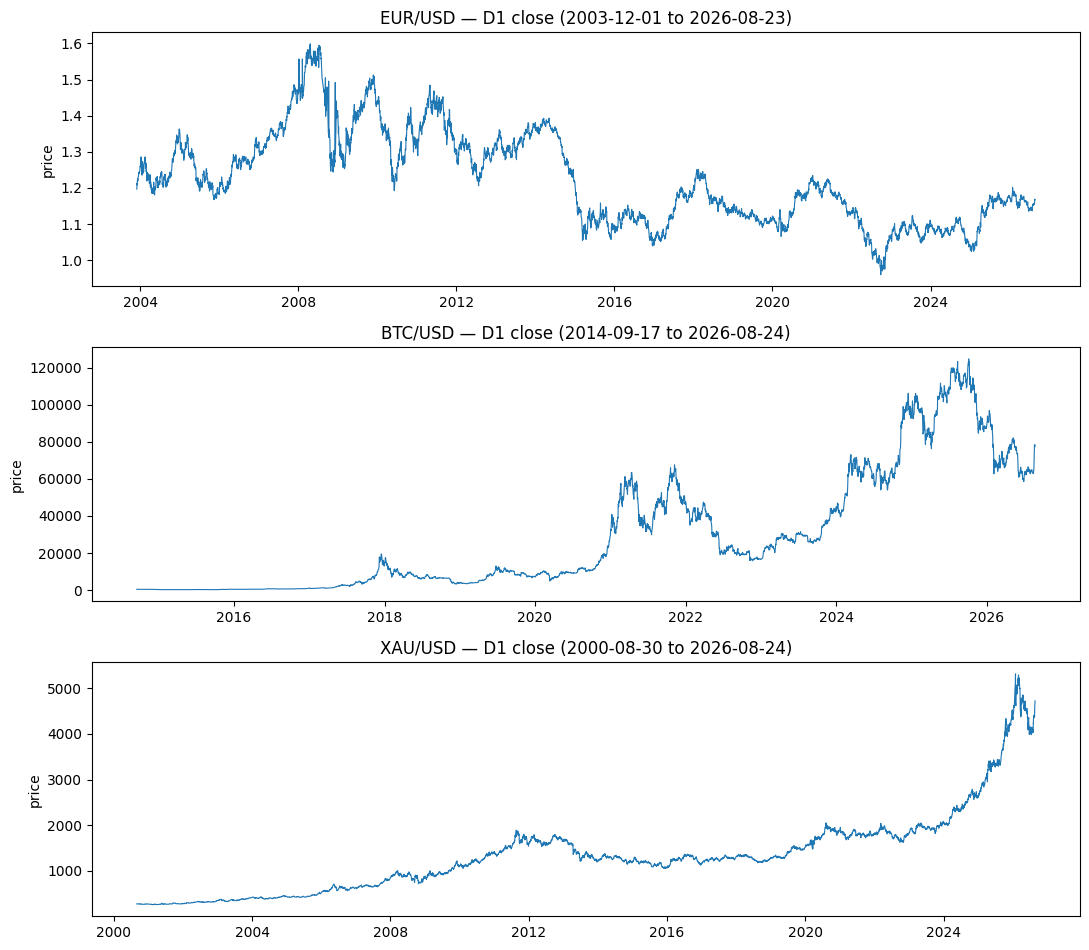

In [9]:
fig, axes = plt.subplots(len(ASSET_KEYS), 1, figsize=(11, 3.2 * len(ASSET_KEYS)), sharex=False)
for ax, asset_key in zip(axes, ASSET_KEYS):
    df = datasets[(asset_key, "D1")]
    ax.plot(df.index, df["close"], linewidth=0.8)
    ax.set_title(f"{ASSETS[asset_key].code} — D1 close ({df.index.min().date()} to {df.index.max().date()})")
    ax.set_ylabel("price")
fig.tight_layout()
plt.show()

## Summary of findings

1. **Schema is consistent** across all 12 (asset x timeframe) datasets — `timestamp` (UTC),
   `asset`, `timeframe`, `open/high/low/close/volume`, matching spec Section 16.
2. **Zero missing OHLCV values** reached `data/processed/` — `validate_and_clean` catches
   NaNs before they get here.
3. **Yahoo Finance daily OHLC data quality issue**: EUR/USD and XAU/USD (GC=F) daily bars have
   a real ~2-7% rate of `close` falling outside `[low, high]`; these rows are dropped, not
   patched. Hourly data for the same assets, and all BTC/USD data, is clean. See
   `docs/data_sources.md` for the full writeup.
4. **Gaps are dominated by expected market closures** — EUR/USD/XAU/USD show weekend-sized
   gaps (~48-56h) on D1/H1/M15; BTC/USD shows very few, very small gaps consistent with a
   24/7 market experiencing occasional brief data outages rather than scheduled closures.
5. **D1 backbone depth is strong**: EUR/USD back to 2003, XAU/USD (proxy) back to 2000,
   BTC/USD back to 2014 — comfortably supports the multi-year walk-forward windows planned
   for Phase 8.

**Next (Phase 4):** compute the five spec-mandated indicators (EMA, RSI, MACD, ATR, Bollinger
Bands) on this cleaned data, still using only information available at each row's timestamp.